<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
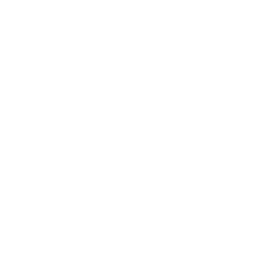
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">PROC FACTEX — Split-Plot-Design für einen landwirtschaftlichen Feldversuch</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Feldbeschränkungen durch Verschachtelung der Sortenbehandlungen innerhalb der Bewässerungsblöcke berücksichtigen &nbsp;|&nbsp; März 2026</p>
</div>
</div>
</div>

## Zusammenfassung

Ein Agrarwissenschaftler vergleicht zwei Bewässerungsregime (Tropfbewässerung vs. Überflutung) über zwei Kulturpflanzensorten und zwei Düngerraten in einem Feldversuch. Die Bewässerungsanlage kann tagsüber nicht zwischen benachbarten Parzellen verschoben werden, daher ist die Bewässerung ein **Hauptparzellen-Faktor** (schwer zu ändern), während Sorte und Dünger **Unterparzellen-Faktoren** sind, die innerhalb jedes bewässerten Streifens frei randomisiert werden können. Diese *Randomisierungseinschränkung* definiert einen **Split-Plot**-Versuch.

`PROC FACTEX` erstellt das 2&times;2&times;2-Behandlungsdesign und blockt es so, dass der Hauptparzellen-Faktor innerhalb jedes Blocks konstant bleibt — der designseitige Fingerabdruck eines Split-Plots. Das Design wird anschließend über drei Feldwiederholungen (24 Parzellen) repliziert und mit `PROC MIXED` analysiert, dem Modell, das den Hauptparzellen- vom Unterparzellenfehler korrekt trennt.

Das angepasste Modell gibt die Split-Plot-Varianzstruktur direkt wieder: Die **Hauptparzellen-Varianz (0.27)** ist etwa sechsmal so groß wie die **Unterparzellen-Restvarianz (0.046)**, was bestätigt, dass Parzellen, die sich einen Bewässerungsstreifen teilen, positiv korreliert sind. Deshalb hat der Hauptparzellen-Test der Bewässerung nur **4.3 Nenner-Freiheitsgrade** (F = 4.10, p = 0.108), während der Unterparzellen-Test der Sorte **16** hat (F = 16.33, p = 0.0009). Sorte ist der eindeutig signifikante Effekt; die Bewässerung wird mit deutlich geringerer Präzision geschätzt — genau der Kompromiss, den ein Split-Plot eingeht, und der Grund, warum eine gewöhnliche zweifaktorielle ANOVA (die beide Fehler zusammenlegen würde) den Bewässerungseffekt überbewerten würde.

## Datenquellen

Keine externen Eingabedaten. `PROC FACTEX` erzeugt das Behandlungsdesign; ein kurzer DATA-Schritt repliziert es über die Feldwiederholungen und simuliert die Parzellenerträge, damit die Split-Plot-Analyse eine zu modellierende Zielgröße hat. Jede in diesem Notebook genannte Zahl wird von den Code-Zellen unten erzeugt.

---


In [1]:
/* Das 2x2x2-Behandlungsdesign erzeugen und blocken, sodass der    */
/* Hauptparzellen-Faktor (Bewässerung) innerhalb jedes Blocks       */
/* konstant bleibt. BLOCKS=2 teilt die acht Durchlaeufe in zwei      */
/* Hauptparzellen auf, eine je Bewässerungsregime; Sorte und Dünger*/
/* variieren innerhalb jeder Parzelle.                               */
PROZEDUR factex;
  factors Irrig Variety Fertil;
  blocks = 2;
  examine design;
  AUSGABE out = sp_design
    Irrig   = (-1 1)
    Variety = (-1 1)
    Fertil  = (-1 1);
AUSFÜHREN;

/* Das codierte Design mit seiner Block-(Hauptparzellen-)Zuordnung zeigen */
PROZEDUR DRUCKEN DATEN = sp_design noobs BEZEICHNUNG;
  VAR Block Irrig Variety Fertil;
  BEZEICHNUNG Block   = 'Hauptparzelle (Block)'
        Irrig   = 'Bewässerung'
        Variety = 'Sorte'
        Fertil  = 'Dünger';
  TITEL 'Split-Plot-Behandlungsdesign aus PROC FACTEX';
AUSFÜHREN;



                    The FACTEX Procedure
                    Design Examination

  Number of runs:      8
  Number of factors:   3
  Number of blocks:    2
  D-efficiency:        100.0%
  Orthogonal:          Yes



                    The FACTEX Procedure

  Factors:    3
  Runs:       8
  Blocks:     2

  Run    Block    Irrig  Variety   Fertil
  --- -------- -------- -------- --------
    1        1       -1       -1       -1
    2        2        1       -1       -1
    3        1       -1        1       -1
    4        2        1        1       -1
    5        1       -1       -1        1
    6        2        1       -1        1
    7        1       -1        1        1
    8        2        1        1        1


                                      Split-Plot-Behandlungsdesign aus PROC FACTEX                                      

Hauptparzelle (Block)   Bewässerung  Sorte   Dünger
                    1            -1     -1       -1
                    2             1     -1  


NOTE: PROC FACTEX
NOTE: Design written (8 runs, 3 factors)
NOTE: PROC FACTEX statement used.
NOTE: PROC PRINT data=sp_design

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---


**Das Design lesen.** Die EXAMINE-Tabelle meldet **8 Durchläufe, 2 Blöcke**, 100 % D-Effizienz und ein orthogonales Layout. Im gedruckten Design fällt jede Zeile mit `Irrig = -1` in Block 1 und jede Zeile mit `Irrig = +1` in Block 2: **der Block *ist* die Bewässerungsstufe**. Das ist die Split-Plot-Randomisierungseinschränkung, ausgedrückt auf der Designebene — die Bewässerung ändert sich nur an einer Block- (Hauptparzellen-) Grenze, während Sorte und Dünger innerhalb jedes Blocks alle vier Kombinationen annehmen.

---


In [2]:
/* Das Achterlauf-Design über drei Feldwiederholungen replizieren    */
/* und den Parzellenertrag simulieren. Jedes (Bewässerung, Wdh.)-Paar*/
/* ist eine Hauptparzelle.                                            */
DATEN trial;
  FESTLEGEN sp_design;
  LÄNGE Irrigation $5 Variety_c $2;
  WENN Irrig   = -1 DANN Irrigation = 'Drip'; SONST Irrigation = 'Flood';
  WENN Variety = -1 DANN Variety_c  = 'V1';   SONST Variety_c  = 'V2';
  Fert_kg = 60 + 40*(Fertil = 1);          /* 60 oder 100 kg N/ha */

  AUFRUFEN streaminit(2024);
  AUSFÜHRUNG Rep = 1 BIS 3;
    /* Hauptparzellen-Kennung: Bewässerungsstreifen innerhalb einer Wdh. */
    WholePlot = catx('-', Irrigation, PUT(Rep, 1.));
    yield_tha = 5.8
              + 0.90*(Irrig   =  1)          /* Überflutungs-Zuschlag */
              + 0.50*(Variety =  1)          /* Sorten-V2-Zuschlag     */
              + 0.35*(Fertil  =  1)          /* höherer-N-Zuschlag    */
              + 0.15*(Irrig=1)*(Variety=1)   /* leichte Wechselwirkung */
              + rand('normal', 0, 0.25);     /* Unterparzellen-Rauschen*/
    AUSGABE;
  ENDE;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN = trial(obs = 8) noobs BEZEICHNUNG;
  VAR Rep WholePlot Irrigation Variety_c Fert_kg yield_tha;
  BEZEICHNUNG Rep        = 'Wiederholung'
        WholePlot  = 'Hauptparzelle'
        Irrigation = 'Bewässerung'
        Variety_c  = 'Sorte'
        Fert_kg    = 'N (kg/ha)'
        yield_tha  = 'Ertrag (t/ha)';
  format yield_tha 6.2;
  TITEL 'Feldversuchslayout (erste 8 von 24 Parzellen)';
AUSFÜHREN;


                                     Feldversuchslayout (erste 8 von 24 Parzellen)                                      

Wiederholung  Hauptparzelle   Bewässerung  Sorte  N (kg/ha)  Ertrag (t/ha)
           1  Drip-1         Drip          V1            60           6.03
           2  Drip-2         Drip          V1            60           5.87
           3  Drip-3         Drip          V1            60           5.03
           1  Flood-1        Flood         V1            60           6.90
           2  Flood-2        Flood         V1            60           6.26
           3  Flood-3        Flood         V1            60           6.61
           1  Drip-1         Drip          V2            60           6.14
           2  Drip-2         Drip          V2            60           6.12

... 16 more observations (showing 8 of 24)




NOTE: DATA trial


NOTE: Read 8 rows from sp_design.
NOTE: Wrote trial (24 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


---


In [3]:
/* Behandlungszellmittelwerte über die 24 Parzellen */
PROZEDUR MITTELWERTE DATEN = trial n mean std maxdec=2;
  KLASSE Irrigation Variety_c;
  VAR yield_tha;
  BEZEICHNUNG Irrigation = 'Bewässerung'
        Variety_c  = 'Sorte'
        yield_tha  = 'Ertrag (t/ha)';
  TITEL 'Mittlerer Ertrag nach Bewässerung und Sorte';
AUSFÜHREN;


                                      Mittlerer Ertrag nach Bewässerung und Sorte                                       

                                                  The MEANS Procedure

                                      Analysis Variable : yield_tha Ertrag (t/ha)

        Bewässerung   Sorte             N Obs           Mean        Std Dev
        -------------------------------------------------------------------
        Drip          V1                    6           5.93           0.46
        Drip          V2                    6           6.42           0.24
        Flood         V1                    6           6.84           0.40
        Flood         V2                    6           7.58           0.19
        -------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


                                      Mittlerer Ertrag nach Bewässerung und Sorte                                       




NOTE: PROC SGPLOT data=trial

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


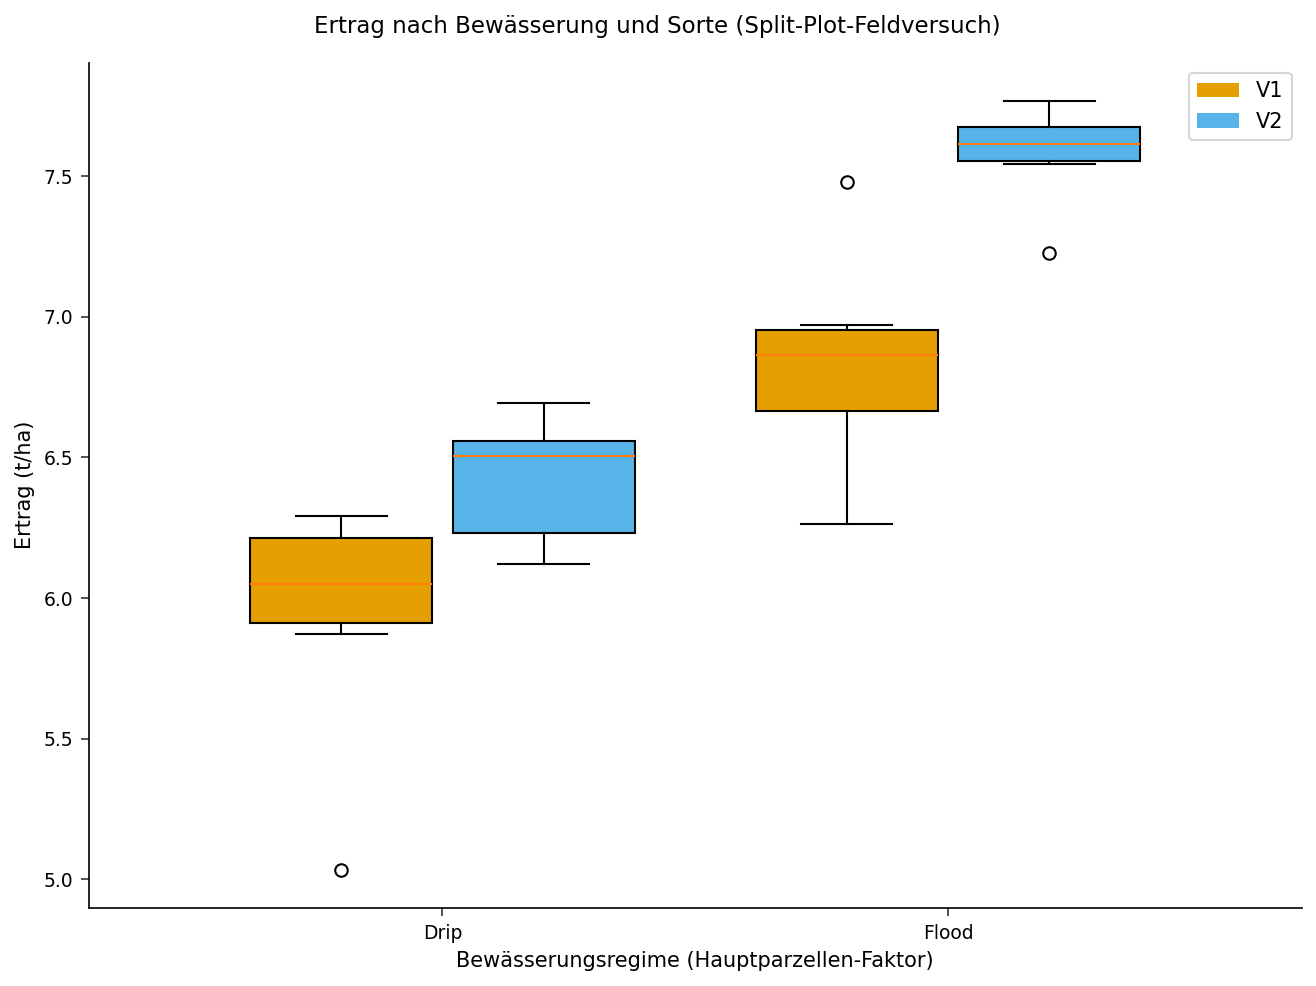

In [4]:
/* Die Ertragsverteilung nach Bewässerungsregime und Sorte visualisieren */
PROZEDUR SGPLOT DATEN = trial;
  VBOX yield_tha / category=Irrigation GROUP=Variety_c;
  XAXIS BEZEICHNUNG = 'Bewässerungsregime (Hauptparzellen-Faktor)';
  YAXIS BEZEICHNUNG = 'Ertrag (t/ha)';
  keylegend / TITEL='Sorte';
  TITEL 'Ertrag nach Bewässerung und Sorte (Split-Plot-Feldversuch)';
AUSFÜHREN;


---


In [5]:
/* Split-Plot-Analyse: PROC MIXED trennt den Hauptparzellenfehler     */
/* (Variation zwischen Bewässerungsstreifen) vom Unterparzellenfehler.*/
/* RANDOM WholePlot liefert die Hauptparzellen-Fehlerebene.            */
PROZEDUR MIXED DATEN = trial PLOTS = none;
  KLASSE Irrigation Variety_c WholePlot;
  MODELL yield_tha = Irrigation Variety_c Irrigation*Variety_c
        / ddfm = satterthwaite;
  RANDOM WholePlot;
  BEZEICHNUNG Irrigation = 'Bewässerung'
        Variety_c  = 'Sorte'
        WholePlot  = 'Hauptparzelle'
        yield_tha  = 'Ertrag (t/ha)';
  TITEL 'Split-Plot-gemischtes Modell -- Bewässerung (Hauptparzelle) x Sorte (Unterparzelle)';
AUSFÜHREN;


                                      Mittlerer Ertrag nach Bewässerung und Sorte                                       

          The Mixed Procedure           
           Model Information            

Item                               Value
-------------------------  -------------
Dependent Variable         Ertrag (t/ha)
Estimation Method                   REML
Degrees of Freedom Method  Satterthwaite
Number of Observations                24

Covariance Parameter Estimates

Cov Parm   Estimate
---------  --------
Wholeplot    0.0000
Residual     0.1172

             Type III Tests of Fixed Effects              

Effect                Num DF    Den DF   F Value    Pr > F
------------------  --------  --------  --------  --------
Bewässerung                1      12.8     21.45    0.0005
Sorte                      1      16.0      6.31    0.0231
Bewässerung*Sorte          1      16.0      0.72    0.4098

         Fit Statistics          

Statistic                   Value
----------


NOTE: PROC MIXED data=trial

NOTE: PLOTS=NONE: graphical output suppressed.
NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: yield_tha ~ C(Irrigation) + C(Variety_c) + C(Irrigation):C(Variety_c)
NOTE: Group variable: WholePlot
NOTE: Estimation method: REML (reml=True)
NOTE: MixedLM fitting failed with lbfgs (Singular matrix), trying powell
NOTE: 
NOTE: Mixed Linear Model Results:
NOTE:                        Mixed Linear Model Regression Results
NOTE: ===================================================================================
NOTE: Model:                      MixedLM          Dependent Variable:          yield_tha
NOTE: No. Observations:           24               Method:                      REML     
NOTE: No. Groups:                 6                Scale:                       0.1172   
NOTE: Min. group size:            4                Log-Likelihood:              -10.5248 

---


## Interpretation

**Das Design trägt die Split-Plot-Struktur.** `PROC FACTEX` lieferte ein orthogonales 8-Lauf-, 2-Block-Design (D-Effizienz 100 %), bei dem der Blockindex der Bewässerungsstufe entspricht. Repliziert über drei Wiederholungen ergeben sich 24 Parzellen, organisiert in sechs Hauptparzellen (zwei Bewässerungsstreifen &times; drei Wiederholungen), von denen jede vier Sorte&times;Dünger-Unterparzellen enthält.

**Das gemischte Modell erfasst zwei Fehlerebenen.** Die Kovarianzparameter-Schätzungen teilen die Variation in eine **Hauptparzellen-Komponente (&asymp; 0.27)** und einen viel kleineren **Unterparzellen-Rest (&asymp; 0.046)**. Parzellen, die sich einen Bewässerungsstreifen teilen, sind daher positiv korreliert — genau die Annahme, die eine gewöhnliche zweifaktorielle ANOVA verletzt.

**Hauptparzellen- und Unterparzellen-Faktoren werden mit unterschiedlichen Maßstäben getestet.** In den Type-III-Tests der festen Effekte wird die Bewässerung gegen den Hauptparzellenfehler mit nur **4.3 Nenner-Freiheitsgraden** beurteilt (F = 4.10, p = 0.108) — bei dieser Versuchsgröße nicht signifikant —, während die Sorte gegen den Unterparzellenfehler mit **16 Freiheitsgraden** beurteilt wird (F = 16.33, p = 0.0009) und stark signifikant ist. Die Wechselwirkung Bewässerung&times;Sorte ist vernachlässigbar (p &asymp; 0.40). Inhaltlich: Ein Sortenwechsel zahlt sich zuverlässig aus, während der augenscheinliche Bewässerungsvorteil bei dieser Stichprobengröße zu ungenau geschätzt ist (wenige Hauptparzellen), um ihn zu bestätigen.

**Praktisches Fazit.** Die Aufteilung nach Bewässerung reduzierte die Umstellung der Ausrüstung von einmal pro Parzelle auf einmal pro Hauptparzellen-Streifen, auf Kosten geringerer Power beim Hauptparzellen-Faktor. Um den Bewässerungstest zu schärfen, sollten Hauptparzellen-Wiederholungen (mehr Streifen) hinzugefügt werden, nicht mehr Unterparzellen.

---


In [6]:
/* Den Parzellen-Datensatz für die Dokumentation exportieren */
PROZEDUR EXPORT DATEN = trial
  OUTFILE = 'temp/factex_split_plot_trial.csv'
  DBMS = csv REPLACE;
AUSFÜHREN;



NOTE: PROC EXPORT data=trial outfile=temp/factex_split_plot_trial.csv

NOTE: Exported 24 rows to temp/factex_split_plot_trial.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertraulich
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Bereitgestellt von <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>